# Tutorial 4: Generative Brain-to-Text (LLM)

This tutorial shows how to generate natural language descriptions of brain activation patterns using a local language model.

**Pipeline (brain → text)**
```
Brain → Autoencoder Encoder → Projection Head → Contrastive Retrieval → LLM → Text
```

**Pipeline (text → brain, with LLM context)**
```
Text Query → to_brain() → [internal text-to-text retrieval] → LLM → Text
```

You will learn:
1. Setting up an LLM backend (Ollama or HuggingFace)
2. Generating text from a brain activation map (brain-to-text mode)
3. Generating text from a text query with neuroscience context (text-to-brain mode)
4. Customising prompts and filtering the context table
5. Labelling multiple networks in a loop

## 0. LLM Backend Setup

`generate_llm_response` supports two backends — pick whichever fits your environment.

### Option A — Ollama (recommended, fast)

```bash
# Install (macOS)
brew install ollama

# Start the server
ollama serve

# Pull a model
ollama pull llama3.2:3b          # lightweight, good quality
ollama pull qwen2.5:3b           # alternative
```

### Option B — HuggingFace (no server required, works offline)

```bash
pip install transformers accelerate
```

Model suggestions:
- `"HuggingFaceTB/SmolLM2-360M-Instruct"` — very fast, ~700 MB
- `"Qwen/Qwen2.5-1.5B-Instruct"` — better quality, ~3 GB
- `"Qwen/Qwen2.5-3B-Instruct"` — best quality, ~6 GB

> **Note:** `model_name` is always required — there is no default. Omitting it raises an error.

In [1]:
import os

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from neurovlm import NeuroVLM
from neurovlm.data import load_latent

nvlm = NeuroVLM(device="cpu")

## 1. Brain-to-Text Generation

When you run `brain(...).to_text()`, the contrastive model retrieves the most similar
publications, NeuroWiki concepts, and CogAtlas terms for the input brain image.

You then inspect the table — filtering it however you like — and pass it directly to
`generate_llm_response` via the `table=` argument. The LLM uses exactly those rows
as context, and is aware the terms were found through neuroimage similarity.

### Load a brain network

In [2]:
# Load pre-encoded network atlases
networks = load_latent("networks_neuro")

# We'll use the auditory network from Du et al.
auditory_network = networks["Du"]["AUD"]

### Step 1 — Contrastive retrieval

Run `brain(...).to_text()` to rank the most similar text across all datasets.
A threshold of 0.4 is a reliable cutoff for meaningful brain-to-text associations.

In [3]:
result = nvlm.brain(auditory_network).to_text()

# Filter to the rows you actually want the LLM to see
context_table = result.top_k(5).query("cosine_similarity > 0.4")
context_table

,dataset,title,description,cosine_similarity
0,cogatlas,auditory stream segregation,The perceptual grouping of sounds to form cohe...,0.437669
1,cogatlas,auditory encoding,The process of storing auditory information in...,0.431347
2,cogatlas,music cognition,The processing of mental functions on auditory...,0.431245
3,cogatlas,acoustic phonetic processing,The cognitive ability to discriminate items on...,0.423635
4,cogatlas,auditory tone detection,Determining the presence of an auditory stimul...,0.417665
5,networks,Auditory,Auditory network (AUD; auditory cortex network...,0.470543
10,pubmed,The processing of temporal pitch and melody in...,An fMRI experiment was performed to identify t...,0.526884
11,pubmed,"Heschl's gyrus, posterior superior temporal gy...",A part of the auditory system automatically de...,0.504547
12,pubmed,Hierarchical processing of sound location and ...,Horizontal sound localization relies on the ex...,0.499913
13,pubmed,Brain bases for auditory stimulus-driven figur...,"Auditory figure-ground segregation, listeners'...",0.490401


### Step 2 — Generate with Ollama

Pass `table=context_table` so the LLM sees exactly the rows you inspected above.

In [5]:
response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="qwen2.5:3b",   # must be pulled first: ollama pull qwen2.5:3b
    table=context_table,         # use the filtered table — k is ignored when table is set
)
print(response)

Generating LLM response from brain input using ollama...
- Using NeuroWiki concepts
- Using CogAtlas terms
LLM writing summary...
Using Ollama model: qwen2.5:3b
LLM finished.
### Overview

The brain activation pattern described by these publications primarily implicates functions related to auditory processing, specifically pitch and melody processing within the auditory cortex. The regions of interest include Heschl's gyrus (HG) and planum temporale (PT), which are well-known for their critical role in auditory scene analysis and early speech sound encoding.

### Analysis

#### Auditory Processing Functions
- **Auditory Network**: The publications highlight how various auditory-related tasks activate primary regions such as HG, PT, and STG. These regions are part of the auditory cortex network (AUD), which includes several functional areas such as Heschl's gyrus for pitch perception, planum temporale for melody processing, and superior temporal gyrus for higher-level auditory function

### Step 2 (alt) — Generate with HuggingFace

Same `table=` argument works with the HuggingFace backend.

In [ ]:
response = nvlm.generate_llm_response(
    backend="huggingface",
    model_name="HuggingFaceTB/SmolLM2-360M-Instruct",
    table=context_table,
    max_new_tokens=256,
)
print(response)

### Querying a single dataset

You can also build the context table from a single dataset — e.g. only CogAtlas concepts.

In [ ]:
# Use only CogAtlas concepts as LLM context
cogatlas_table = result.top_k(5, dataset="cogatlas").query("cosine_similarity > 0.4")
print(cogatlas_table[["title", "cosine_similarity"]])

response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="llama3.2:3b",
    table=cogatlas_table,
)
print(response)

## 2. Text-to-Brain Generation

When you run `text(...).to_brain()`, NeuroVLM generates (or retrieves) brain maps
for your query.

Calling `generate_llm_response` afterwards automatically runs a text-to-text
similarity search **internally** — you do not need to call `to_text()` yourself.
The LLM uses the resulting publications and concepts as context to:
- Define the user's query term
- Explain how the top neuroscience concepts relate to it

The brain result stored on the instance is **not overwritten**.

### Generate a brain map, then describe the concept

There are adapters available but none are activated for the forward pass.


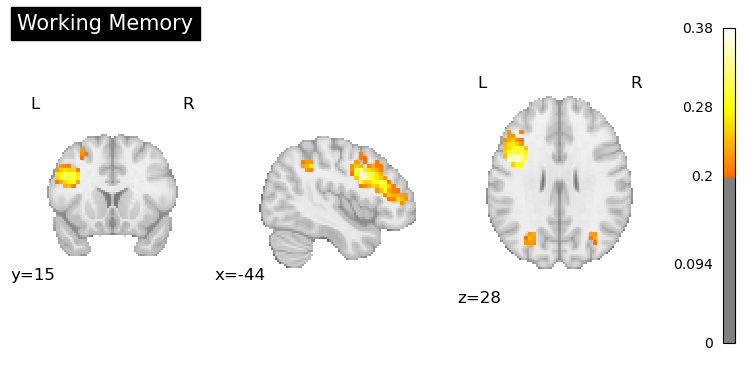

In [6]:
# Generate brain map from text
brain_result = nvlm.text("working memory").to_brain(head="mse")
brain_result.plot(threshold=0.2, title="Working Memory");

In [8]:
# Internal text-to-text retrieval happens automatically; k controls how many rows it fetches
response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="qwen2.5:3b",
    k=5,
)
print(response)

[text-to-brain] Running internal text-to-text retrieval for query: 'working memory' to build LLM context...
Generating LLM response for query: 'working memory' using ollama...
- Using papers
- Using CogAtlas terms
LLM writing summary...
Using Ollama model: qwen2.5:3b
LLM finished.
### Overview

The publications examined the neurocognitive underpinnings of deductive reasoning, arithmetic processing, compensatory brain activity during working memory tasks, and task switching ability in children and healthy older adults. They also explored the role of the left angular gyrus (lAG) in mental arithmetic, as well as the effects of APOE ε4 on neuronal resource use during working memory processing.

### Key Findings

#### Deductive Reasoning
- Higher parental education was associated with greater reliance on the left inferior frontal gyrus when solving set-inclusion problems.
- Lower parental education children who have higher nonverbal skills relied more on right parietal areas to solve set-in

In [ ]:
# The brain result is still available — it was not overwritten
brain_result.plot(threshold=0.2, title="Working Memory (still available)");

## 3. Adding a Custom User Prompt

Pass `user_prompt` to steer the LLM's focus — e.g. ask a specific question or
request a particular output format.

In [ ]:
result = nvlm.brain(networks["YeoLab"]["DefaultA"]).to_text()
context_table = result.top_k(5).query("cosine_similarity > 0.4")

response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="llama3.2:3b",
    table=context_table,
    user_prompt="What clinical conditions are associated with this network?",
)
print(response)

In [ ]:
# Request a concise bullet-point summary
result = nvlm.brain(networks["YeoLab"]["SomMotA"]).to_text()
context_table = result.top_k(5).query("cosine_similarity > 0.4")

response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="llama3.2:3b",
    table=context_table,
    user_prompt="Summarise in three bullet points, suitable for a non-expert audience.",
)
print(response)

## 4. Labelling Multiple Networks

Loop over networks: run contrastive retrieval, inspect the filtered table,
then pass it to `generate_llm_response`.

In [ ]:
target_networks = {
    "Visual":       networks["YeoLab"]["VisualA"],
    "Auditory":     networks["Du"]["AUD"],
    "Motor":        networks["YeoLab"]["SomMotA"],
    "Default Mode": networks["YeoLab"]["DefaultA"],
    "Language":     networks["Du"]["LANG"],
}

for name, latent in target_networks.items():
    print(f"\n{'='*60}")
    print(f"Network: {name}")
    print('='*60)

    result = nvlm.brain(latent).to_text()

    # Build and inspect the filtered context table
    context_table = result.top_k(5).query("cosine_similarity > 0.4")
    if not context_table.empty:
        print(context_table[["dataset", "title", "cosine_similarity"]].to_string(index=False))
    else:
        print("(no matches above threshold)")
        continue  # skip generation if nothing passed the threshold

    # Generate using exactly the rows above
    response = nvlm.generate_llm_response(
        backend="ollama",
        model_name="llama3.2:3b",
        table=context_table,
        verbose=False,
    )
    print(f"\n{response}")

## 5. Querying a Specific Dataset Before Generating

Pass `datasets` to `to_text()` to retrieve only from one source, then build
the context table from that restricted result.

In [ ]:
# Retrieve only PubMed papers for the visual network
visual = networks["YeoLab"]["VisualA"]
result = nvlm.brain(visual).to_text(datasets=["pubmed"])

context_table = result.top_k(3, dataset="pubmed")
print("Papers used as context:")
print(context_table[["title", "cosine_similarity"]].to_string(index=False))

In [ ]:
# LLM will only have paper context (no wiki or cogatlas)
response = nvlm.generate_llm_response(
    backend="ollama",
    model_name="llama3.2:3b",
    table=context_table,
)
print(response)

## 6. Summary

In this tutorial you learned:

1. **LLM backends**: Ollama (fast, requires local server) and HuggingFace (offline, no server).
   `model_name` is always required — there is no default.

2. **Brain-to-text mode** (`brain(...).to_text()` → `generate_llm_response`):
   - Contrastive retrieval ranks the most similar publications, NeuroWiki concepts,
     and CogAtlas terms for the input brain map.
   - You inspect and filter the table yourself (e.g. `top_k(5).query("cosine_similarity > 0.4")`).
   - Pass `table=` to `generate_llm_response` — the LLM sees exactly those rows.
   - The LLM frames the terms in the context of neuroimage similarity.

3. **Text-to-brain mode** (`text(...).to_brain()` → `generate_llm_response`):
   - An internal text-to-text retrieval is run automatically — no extra call needed.
   - Use `k=` to control how many rows are fetched internally.
   - The LLM defines the user's query term and explains how the top neuroscience
     concepts relate to it. The stored brain result is preserved.

4. **`user_prompt`**: steer the LLM towards a specific question or output format.

5. **Batch labelling**: loop over networks — build the filtered `context_table` per network
   and pass it to `generate_llm_response`.

6. **Dataset filtering**: pass `datasets=["pubmed"]` (or any subset) to `to_text()`
   to restrict what context the LLM receives.

**Key tip**: larger models (≥ 7B parameters) produce noticeably better responses.
For production use, prefer `qwen2.5:7b-instruct` or `llama3.1:8b` via Ollama.